# E08 · Physics-based models: weighing the universe with supernovae

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Union2.1: redshift and distance modulus of 580 type Ia supernovae (Suzuki et al. 2012) |
| **You will learn** | Using a physical theory as the regression function · a differentiable numerical integral inside a PyMC model (Gauss-Legendre quadrature in pure PyTensor) · checking it against SciPy · diagnosing and removing an exact parameter degeneracy · curved ("banana") posteriors · LOO as a scientific question · pushing posterior draws through more physics |

In E01-E06 the regression function was something *we chose*: a line, a spline, a GP. Here
we do not get to choose. General relativity plus a list of what the universe contains
predicts, with no free functional form, how bright a standard candle looks at redshift
$z$. **The theory is the regression function.** That changes the character of every step:

- parameters have **units and meaning** (the fraction of the universe that is matter), so
  priors come from physics rather than from "weakly informative" folklore;
- **extrapolation is principled** - the curve beyond the data is a prediction of the
  theory, not the whim of a basis function;
- **model comparison answers a scientific question**. "Does the model with a cosmological
  constant predict better than the one without?" is the question that won the 2011 Nobel
  prize in physics: *is the expansion of the universe accelerating?*

The price is computational: the theory contains an integral with no closed form, and it
has to live inside the model, differentiable, for 580 supernovae at once.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy import integrate, stats

from pymc_challenges import data

RANDOM_SEED = 1998
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Question and data

A type Ia supernova is a white dwarf that explodes at (very nearly) a fixed mass, so its
peak luminosity is (very nearly) the same everywhere: a **standard candle**. Compare how
bright it *is* (absolute magnitude $M$) with how bright it *looks* (apparent magnitude $m$)
and you have its distance, reported as the **distance modulus**

$$\mu = m - M = 5\log_{10}\!\frac{d_L}{10\ \text{pc}}$$

where $d_L$ is the luminosity distance. Five magnitudes are a factor 100 in flux, so
$\Delta\mu = 0.1$ is about 5% in distance. The redshift $z$ of the host galaxy says how
much the universe has expanded since the light left. Distance against redshift - the
**Hubble diagram** - is therefore a record of the expansion history.

In [2]:
data.describe("supernovae")
sn = data.load("supernovae").sort_values("z").reset_index(drop=True)
z_obs, mu_obs, mu_err = sn.z.values, sn.mu.values, sn.mu_err.values
sn.describe().round(3)

supernovae: 580 type Ia supernovae: redshift z, distance modulus mu and its error.
  source: Supernova Cosmology Project, Union2.1 compilation (Suzuki et al. 2012).
  url:    https://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt


,z,mu,mu_err,p_low_mass_host
count,580.000,580.000,580.000,580.000
mean,0.362,40.028,0.223,0.424
std,0.327,3.196,0.126,0.277
min,0.015,33.825,0.084,0.000
25%,0.055,36.920,0.151,0.128
50%,0.294,40.884,0.189,0.552
75%,0.552,42.518,0.242,0.552
max,1.414,45.411,1.007,1.000


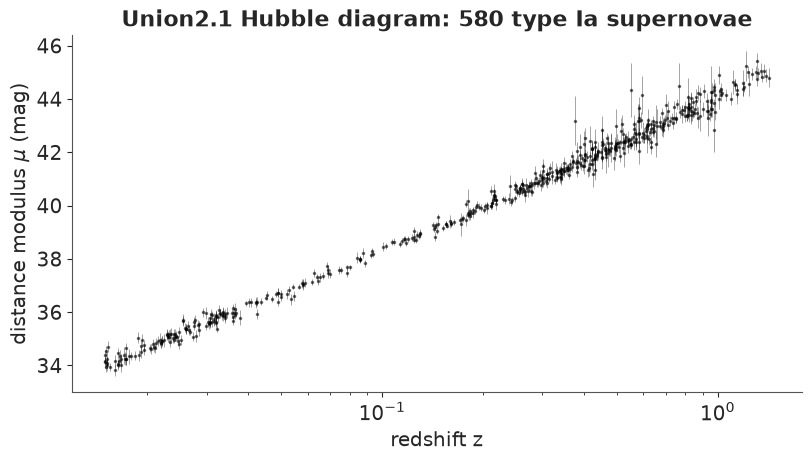

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(z_obs, mu_obs, yerr=mu_err, fmt=".", ms=3, lw=0.5, color="k", alpha=0.5)
ax.set(xscale="log", xlabel="redshift z", ylabel=r"distance modulus $\mu$ (mag)",
       title="Union2.1 Hubble diagram: 580 type Ia supernovae");

Nearly twelve magnitudes of dynamic range and a curve that looks like a boring logarithm. Almost
all of that is just "further away is fainter". Everything interesting - the entire
evidence for dark energy - is a deviation of **a few tenths of a magnitude** at $z > 0.3$,
comparable to the error bar of a single supernova. We will need a better way to look at it
(section 5) and a model that uses all 580 objects at once.

## 2 · The physics, compactly

In a homogeneous, isotropic universe the expansion rate is $H(z) = H_0\,E(z)$, where the
Friedmann equation gives the dimensionless function

$$E(z)^2 = \Omega_m (1+z)^3 + \Omega_k (1+z)^2 + \Omega_{\Lambda}\,(1+z)^{3(1+w)},
\qquad \Omega_k = 1 - \Omega_m - \Omega_\Lambda .$$

$\Omega_m$ is today's matter density and $\Omega_\Lambda$ the dark-energy density, both as
fractions of the critical density; $\Omega_k$ is whatever is left over and shows up as
spatial curvature. $w$ is the dark-energy equation of state (pressure / energy density):
$w=-1$ is Einstein's cosmological constant, whose density does not dilute as space expands.

Light travelling towards us covers the dimensionless comoving distance

$$\chi(z) = \int_0^z \frac{dz'}{E(z')}$$

and the luminosity distance is

$$d_L(z) = (1+z)\,\frac{c}{H_0}\;\text{sinn}(\chi;\Omega_k), \qquad
\text{sinn}(\chi;\Omega_k) =
\begin{cases}
\sinh(\sqrt{\Omega_k}\,\chi)/\sqrt{\Omega_k} & \Omega_k > 0 \ \text{(open)}\\
\chi & \Omega_k = 0 \ \text{(flat)}\\
\sin(\sqrt{-\Omega_k}\,\chi)/\sqrt{-\Omega_k} & \Omega_k < 0 \ \text{(closed)}
\end{cases}$$

With $c$ in km/s and $H_0$ in km/s/Mpc, $c/H_0$ is in Mpc, and 1 Mpc = $10^5 \times$ 10 pc, so

$$\mu(z) = \underbrace{5\log_{10}\big[(1+z)\,\text{sinn}(\chi)\big]}_{\text{shape: depends on }\Omega_m,\,\Omega_\Lambda,\,w}
\;+\; \underbrace{25 + 5\log_{10}\frac{c}{H_0\,[\text{Mpc}]}}_{\text{a constant}} .$$

Every model in this notebook is a **constraint on the same function**:

| model | $\Omega_m$ | $\Omega_\Lambda$ | $w$ | story |
|---|---|---|---|---|
| (a) Einstein-de Sitter | 1 | 0 | - | matter only; the textbook universe before 1998 |
| (b) flat $\Lambda$CDM | free | $1-\Omega_m$ | $-1$ | today's standard model |
| (c) curved $\Lambda$CDM | free | free | $-1$ | let the data decide on flatness |
| (d) flat $w$CDM | free | $1-\Omega_m$ | free | is dark energy really a constant? |

The quantity that answers the headline question is the **deceleration parameter** today,
$q_0 = -\ddot a a/\dot a^2 = \tfrac12\Omega_m + \tfrac12(1+3w)\,\Omega_\Lambda$, which for
$w=-1$ is $\Omega_m/2 - \Omega_\Lambda$. Matter pulls the brake; $q_0 < 0$ means the
expansion is speeding up.

## 3 · The computational core: an integral inside the model

$\chi(z)$ has no closed form for general $(\Omega_m, \Omega_\Lambda, w)$. NUTS needs the
log-density **and its gradient** with respect to the parameters, so
`scipy.integrate.quad` is out: PyTensor cannot differentiate through it. Options:

1. **Fixed-order Gauss-Legendre quadrature per supernova.** Map the $K$ nodes $x_k$ and
   weights $w_k$ from $[-1, 1]$ onto $[0, z_i]$:
   $\chi(z_i) \approx \frac{z_i}{2}\sum_k w_k \,/\, E\!\big(\tfrac{z_i}{2}(x_k+1)\big)$.
   That is a $(580 \times K)$ array of plain arithmetic - trivially vectorised, and
   differentiable because it *is* just arithmetic. $1/E$ is very smooth, so a small $K$
   gives machine precision.
2. A cumulative trapezoid/Simpson rule on a fine shared $z$-grid, then interpolate to each
   $z_i$. Fine too, but the accuracy depends on grid *and* interpolation.
3. Write the integral in JAX and bring it in with `pytensor.wrap_jax` (the subject of E09).
   The right tool when the numerics need adaptive control flow; overkill here.

We take option 1. The functions below only use arithmetic, `sqrt`, `log10` and `maximum`,
so the *same code* runs on NumPy arrays (for checking and for posterior curves) and on
PyTensor variables (inside the model) - pass `xp=np` or `xp=pt`, as C01 did.

One subtlety: $\text{sinn}$. The obvious `pt.switch` between `sinh`, `sin` and $\chi$
returns the right *value* everywhere, but its *gradient* at $\Omega_k = 0$ - exactly where
flat models live - is NaN: the derivative of $\sqrt{|\Omega_k|}$ in the unused branches is
infinite there and leaks through the switch. But $\text{sinn}$ is an entire function of
$\Omega_k$: both branches are the *same* power series
$\chi\,\sum_n (\Omega_k\chi^2)^n/(2n+1)!$. For $|\Omega_k\chi^2| \lesssim 2$, which covers
anything remotely relevant, nine terms are exact to double precision. No branches, no NaN.

In [4]:
C_KMS = 299_792.458  # speed of light, km/s
H0_FID = 70.0  # km/s/Mpc - the value the published mu assume (section 4)
MU0_FID = 25 + 5 * np.log10(C_KMS / H0_FID)  # the constant in mu(z) for h = 0.7


def _nodes_axis(p):
    """Give array-valued parameters a trailing axis so they broadcast against quadrature nodes."""
    return p[..., None] if getattr(p, "ndim", 0) > 0 else p


def E2(z, Om, OL, w=-1.0):
    """Friedmann equation: (H(z) / H0)^2 for matter + curvature + dark energy."""
    Ok = 1 - Om - OL
    return Om * (1 + z) ** 3 + Ok * (1 + z) ** 2 + OL * (1 + z) ** (3 * (1 + w))


def comoving_distance(z, Om, OL, w=-1.0, xp=np, n_nodes=16):
    """chi(z) = int_0^z dz'/E(z') by Gauss-Legendre quadrature; z has shape (..., N)."""
    x_k, w_k = np.polynomial.legendre.leggauss(n_nodes)
    nodes = 0.5 * z[..., None] * (x_k + 1)  # (..., N, K) points inside [0, z_i]
    e2 = E2(nodes, _nodes_axis(Om), _nodes_axis(OL), _nodes_axis(w))
    e2 = xp.maximum(e2, 1e-8)  # E^2 <= 0 means "no Big Bang": see model (c)
    return 0.5 * z * (w_k / xp.sqrt(e2)).sum(-1)


def sinn(chi, Ok, n_terms=9):
    """sinh(sqrt(Ok) chi)/sqrt(Ok), chi, or sin(sqrt(-Ok) chi)/sqrt(-Ok) - as one power series."""
    u = Ok * chi**2
    term, total = 1.0, 1.0
    for n in range(1, n_terms):
        term = term * u / ((2 * n) * (2 * n + 1))
        total = total + term
    return chi * total


def mu_shape(z, Om, OL, w=-1.0, xp=np, n_nodes=16):
    """5 log10 of the dimensionless luminosity distance (H0/c) d_L. Add MU0_FID for h = 0.7."""
    chi = comoving_distance(z, Om, OL, w, xp=xp, n_nodes=n_nodes)
    return 5 * xp.log10((1 + z) * sinn(chi, 1 - Om - OL))

### Verify before you trust

A numerical approximation inside a likelihood is a silent source of bias, so we test it
three ways before it goes anywhere near a sampler.

**Units.** A standard benchmark: for $\Omega_m = 0.3$, flat, $h = 0.7$, the distance
modulus at $z = 0.5$ is 42.26. And the empty ("Milne") universe has the closed form
$(H_0/c)\,d_L = z(1 + z/2)$, which exercises the $\sinh$ branch of the series.

In [5]:
print(f"mu(z=0.5 | Om=0.3, flat, h=0.7) = {float(mu_shape(np.array([0.5]), 0.3, 0.7)[0] + MU0_FID):.3f}")

z_test = np.array([0.01, 0.1, 0.5, 1.0, 1.414, 3.0])
milne_exact = 5 * np.log10(z_test * (1 + z_test / 2))
print("empty universe, max |error| vs closed form:", np.abs(mu_shape(z_test, 0.0, 0.0) - milne_exact).max())

mu(z=0.5 | Om=0.3, flat, h=0.7) = 42.261
empty universe, max |error| vs closed form: 7.993605777301127e-15


**Accuracy against adaptive quadrature**, at every observed redshift, for cosmologies
spread over (and beyond) the region the sampler will explore - including strongly open,
closed and phantom ($w < -1$) cases - as a function of the number of nodes:

In [6]:
def mu_shape_quad(z, Om, OL, w=-1.0):
    """Reference implementation: scipy.integrate.quad and explicit sin/sinh branches."""
    chi = integrate.quad(lambda x: 1 / np.sqrt(E2(x, Om, OL, w)), 0, z, epsabs=1e-13, epsrel=1e-13)[0]
    Ok = 1 - Om - OL
    if Ok > 1e-12:
        chi = np.sinh(np.sqrt(Ok) * chi) / np.sqrt(Ok)
    elif Ok < -1e-12:
        chi = np.sin(np.sqrt(-Ok) * chi) / np.sqrt(-Ok)
    return 5 * np.log10((1 + z) * chi)


test_cosmologies = {
    "Einstein-de Sitter (1, 0)": (1.0, 0.0, -1.0),
    "flat LCDM (0.3, 0.7)": (0.3, 0.7, -1.0),
    "open (0.2, 0)": (0.2, 0.0, -1.0),
    "closed (0.8, 1.2)": (0.8, 1.2, -1.0),
    "phantom w=-2 (0.3, 0.7)": (0.3, 0.7, -2.0),
    "w=-0.5 (0.1, 0.9)": (0.1, 0.9, -0.5),
}
accuracy = {}
for label, pars in test_cosmologies.items():
    exact = np.array([mu_shape_quad(zi, *pars) for zi in z_obs])
    accuracy[label] = {K: np.abs(mu_shape(z_obs, *pars, n_nodes=K) - exact).max() for K in (2, 4, 8, 16)}

pd.DataFrame(accuracy).T.rename_axis("max |error| in mag, by number of nodes", axis=1).map("{:.1e}".format)

"max |error| in mag, by number of nodes",2,4,8,16
"Einstein-de Sitter (1, 0)",1.6e-02,5.1e-05,3.5e-10,1.8e-15
"flat LCDM (0.3, 0.7)",3.6e-03,7.7e-06,2.3e-11,1.8e-15
"open (0.2, 0)",9.2e-03,2.1e-05,1.1e-10,2.7e-15
"closed (0.8, 1.2)",9.9e-03,3.9e-05,7.1e-09,1.8e-15
"phantom w=-2 (0.3, 0.7)",3.4e-02,5.4e-04,1.7e-07,9.8e-15
"w=-0.5 (0.1, 0.9)",4.2e-03,8.2e-06,3.5e-11,1.8e-15


The smallest measurement error in the data is 0.08 mag. Four nodes would already be more
than good enough; with 16 the quadrature error is at the level of floating-point rounding
($10^{-14}$ mag) for every test case, exotic ones included. We keep 16: a $580 \times 16$
array costs nothing.

**Gradient.** Finally, check that PyTensor differentiates through the whole thing, by
comparing $\partial\mu/\partial\Omega_m$ with a finite difference.

In [7]:
Om_, OL_, w_ = pt.dscalars("Om", "OL", "w")
mu_graph = mu_shape(z_test, Om_, OL_, w_, xp=pt)
dmu_dOm = pytensor.function([Om_, OL_, w_], pytensor.gradient.jacobian(mu_graph, Om_))

eps = 1e-6
finite_diff = (mu_shape(z_test, 0.3 + eps, 0.7) - mu_shape(z_test, 0.3 - eps, 0.7)) / (2 * eps)
pd.DataFrame({"z": z_test, "autodiff": dmu_dOm(0.3, 0.7, -1.0), "finite difference": finite_diff}).round(6)

,z,autodiff,finite difference
0,0.010,-0.005500,-0.005500
1,0.100,-0.061000,-0.061000
2,0.500,-0.392660,-0.392660
3,1.000,-0.851740,-0.851740
4,1.414,-1.193284,-1.193284
5,3.000,-2.116422,-2.116422


Note the size of the signal: at $z = 1$, changing $\Omega_m$ by 0.1 (at fixed
$\Omega_\Lambda$) moves $\mu$ by less than a tenth of a magnitude, while a single supernova
is measured to about 0.2 mag. This is a many-objects, small-effect problem - exactly where a
joint probabilistic model earns its keep.

## 4 · Something goes wrong: $H_0$ and $M$

Let us write the "obvious" flat $\Lambda$CDM model. The theory has two parameters,
$\Omega_m$ and $H_0$, so give both a prior: $\Omega_m \sim \text{Uniform}(0,1)$ and
$H_0 \sim \text{Uniform}(40, 100)$ km/s/Mpc, which brackets every measurement of the last
fifty years. And a standard candle is only useful if you know its wattage: the published
$\mu$ were computed with an *assumed* absolute magnitude $M$, which could be off, so add
$\delta M \sim \text{Normal}(0, 1)$ for the calibration error. Finally, supernovae are not
perfectly standard: add an **intrinsic scatter** $\sigma_\text{int}$ in quadrature to the
quoted errors, with a prior that knows type Ia scatter is of order 0.1 mag.

$$\mu_i^\text{obs} \sim \text{Normal}\Big(\mu_\text{shape}(z_i;\Omega_m) + 25 + 5\log_{10}\tfrac{c}{H_0} + \delta M,\ \
\sqrt{\sigma_i^2 + \sigma_\text{int}^2}\Big)$$

In [8]:
coords = {"sn": sn.name.values}

with pm.Model(coords=coords) as naive_model:
    Om = pm.Uniform("Om", 0.0, 1.0)
    H0 = pm.Uniform("H0", 40.0, 100.0)  # floats! see the note below
    dM = pm.Normal("dM", 0.0, 1.0)
    sigma_int = pm.HalfNormal("sigma_int", 0.2)

    mu = mu_shape(z_obs, Om, 1 - Om, xp=pt) + 25 + 5 * pt.log10(C_KMS / H0) + dM
    pm.Normal("mu_obs", mu, pt.sqrt(mu_err**2 + sigma_int**2), observed=mu_obs, dims="sn")

    naive_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(naive_idata.sample_stats["diverging"].sum()))
az.summary(naive_idata, round_to=3)

NUTS[nutpie]: [Om, H0, dM, sigma_int]


divergences: 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
dM,0.065,0.523,-0.955,0.683,46.266,237.059,1.091,0.085,0.022
Om,0.279,0.020,0.249,0.312,457.031,268.529,1.010,0.001,0.000
H0,74.081,16.214,45.027,95.789,46.380,234.363,1.091,2.748,0.583
sigma_int,0.017,0.012,0.001,0.040,660.080,605.361,1.004,0.000,0.000


(A PyMC trap met on the way: `pm.Uniform("H0", 40, 100)` with **integer** bounds gives a
NaN initial point and nutpie dies with "All initialization points failed" - small
integer constants become `int8`, and $40 + 100$ overflows where the interval transform
computes its starting point. `Uniform(0, 1)` is unaffected. Write bounds as floats.)

`H0` and `dM` are in trouble: `r_hat` of 1.09 and an effective sample size below 50 out of
4000 draws, plus a few divergences. Even `Om`, which the data constrain well, mixes worse
than it should. The pair plot shows why.

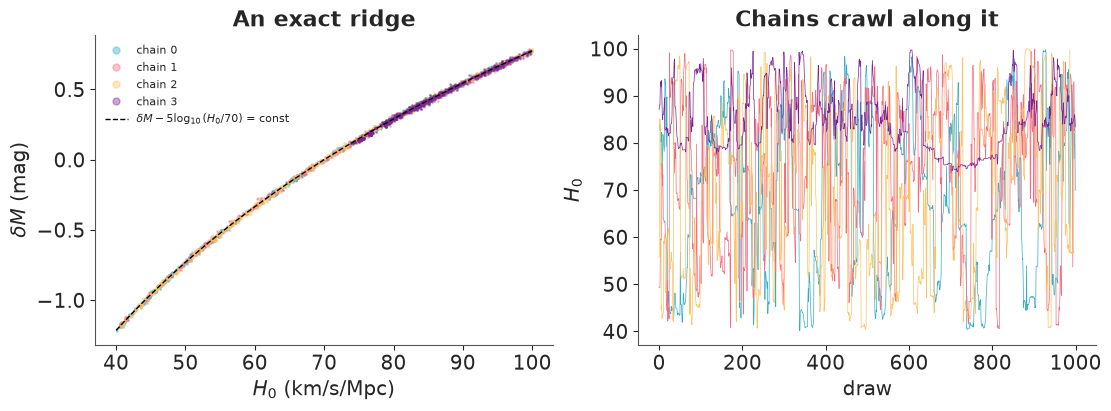

In [9]:
naive_post = naive_idata.posterior
h_line = np.linspace(40, 100, 200)
ridge_const = float((naive_post["dM"] - 5 * np.log10(naive_post["H0"] / H0_FID)).mean())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for chain in naive_post.chain.values:
    axes[0].plot(naive_post["H0"].sel(chain=chain), naive_post["dM"].sel(chain=chain), ".", ms=2,
                 alpha=0.4, label=f"chain {chain}")
axes[0].plot(h_line, ridge_const + 5 * np.log10(h_line / H0_FID), "k--", lw=1,
             label=r"$\delta M - 5\log_{10}(H_0/70)$ = const")
axes[0].set(xlabel=r"$H_0$ (km/s/Mpc)", ylabel=r"$\delta M$ (mag)", title="An exact ridge")
axes[0].legend(markerscale=5, fontsize=8)
axes[1].plot(naive_post["H0"].values.T, lw=0.5)
axes[1].set(xlabel="draw", ylabel=r"$H_0$", title="Chains crawl along it");

In [10]:
combo = naive_post["dM"] - 5 * np.log10(naive_post["H0"] / H0_FID)
print(f"posterior sd of H0          : {float(naive_post['H0'].std()):.1f}   (prior sd of Uniform(40, 100): {60 / np.sqrt(12):.1f})")
print(f"posterior sd of dM          : {float(naive_post['dM'].std()):.2f}")
print(f"posterior sd of the combo   : {float(combo.std()):.3f}")

posterior sd of H0          : 16.2   (prior sd of Uniform(40, 100): 17.3)
posterior sd of dM          : 0.52
posterior sd of the combo   : 0.011


Every draw sits on the curve $\delta M - 5\log_{10}H_0 = \text{const}$. Look back at the
likelihood: $H_0$ and $\delta M$ enter **only through that sum**. A universe that expands
10% faster with supernovae that are 0.2 mag fainter produces *exactly* the same data. No
amount of supernovae can separate them; the data pin the combination to about a hundredth
of a magnitude, and along the ridge the posterior is simply the prior (the posterior sd of
$H_0$ is nearly that of `Uniform(40, 100)`; the $\delta M$ prior trims the ends a little). A
ridge fifty times longer than it is wide, curved, with hard walls at both ends, is
miserable for a sampler with a diagonal mass matrix - hence the diagnostics.

The tempting reaction is to turn sampler knobs:

In [11]:
with naive_model:
    naive_idata_095 = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED)

print("divergences:", int(naive_idata_095.sample_stats["diverging"].sum()))
print(f"posterior sd of H0: {float(naive_idata_095.posterior['H0'].std()):.1f}")
az.summary(naive_idata_095, var_names=["H0", "dM"], round_to=3)

NUTS[nutpie]: [Om, H0, dM, sigma_int]


divergences: 0
posterior sd of H0: 15.7


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
H0,70.292,15.745,45.868,95.225,385.163,461.452,1.012,0.790,0.339
dM,-0.048,0.508,-0.913,0.669,385.334,461.663,1.012,0.026,0.013


The diagnostics now look almost respectable, and **nothing has been learned**: the
"posterior" of $H_0$ is still the prior. This is the dangerous version of the problem -
more careful sampling hides the symptom, and a reader of the summary table would happily report
$H_0 \approx 70 \pm 16$ "from supernovae". It is **not** a sampler problem. The model asks
the data a question they cannot answer.

(This is why measuring $H_0$ needs a *distance ladder*: Cepheids or some other rung to
calibrate $M$ independently. It is also why the tension between different $H_0$
measurements does not touch the evidence for acceleration, which lives in the *shape*.)

**The fix is to model what is identified.** Collapse the two into one nuisance parameter:

$$\text{offset} = \delta M - 5\log_{10}(h/0.7)$$

The Union2.1 distance moduli are published for a fiducial calibration equivalent to
$h = H_0/100 = 0.7$, so we write $\mu = \mu_\text{shape} + \mu_0(h{=}0.7) + \text{offset}$
and expect an offset near zero. Its prior can come from physics: $h$ between 0.5 and 1 is
$\pm 0.75$ mag, so `Normal(0, 0.5)` is honest. Because the offset enters linearly with
Gaussian noise it could even be integrated out analytically, as many published analyses
do; we sample it instead, so that the pointwise log-likelihood needed for LOO stays simple.

Every model below shares the same nuisance parameters and likelihood, so wrap them once:

In [12]:
def hubble_likelihood(shape, student_t=False):
    """Shared part of every model: identified offset, intrinsic scatter, likelihood."""
    offset = pm.Normal("offset", 0.0, 0.5)
    sigma_int = pm.HalfNormal("sigma_int", 0.2)
    mu = pm.Deterministic("mu", shape + MU0_FID + offset, dims="sn")
    sigma = pt.sqrt(mu_err**2 + sigma_int**2)
    if student_t:
        nu = pm.Gamma("nu", 2.0, 0.1)
        pm.StudentT("mu_obs", nu=nu, mu=mu, sigma=sigma, observed=mu_obs, dims="sn")
    else:
        pm.Normal("mu_obs", mu, sigma, observed=mu_obs, dims="sn")


with pm.Model(coords=coords) as flat_model:
    Om = pm.Uniform("Om", 0.0, 1.0)
    pm.Deterministic("OL", 1 - Om)
    hubble_likelihood(mu_shape(z_obs, Om, 1 - Om, xp=pt))

flat_model

## 5 · Prior predictive check, in the Hubble diagram

$\Omega_m \sim \text{Uniform}(0, 1)$ is the physical range for a flat universe with
non-negative matter and dark-energy densities. What does the prior claim about data?

The raw Hubble diagram hides everything (section 1), so cosmologists plot residuals
against a reference: the **empty universe** ($\Omega_m = \Omega_\Lambda = 0$), which
neither accelerates nor decelerates. Points *above* zero are fainter - further away - than
coasting would predict: the expansion has sped up since the light left. Below zero: slowed down.

Sampling: [Om, mu_obs, offset, sigma_int]


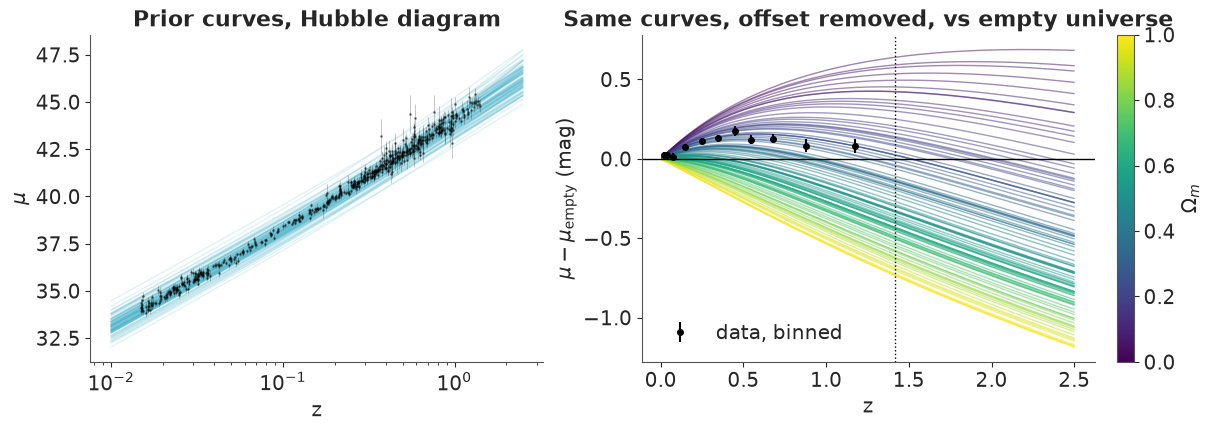

In [13]:
with flat_model:
    flat_idata = pm.sample_prior_predictive(500, var_names=["Om", "offset", "sigma_int", "mu_obs"],
                                            random_seed=RANDOM_SEED)


def milne(z):
    """Distance modulus of the empty universe for h = 0.7 - the reference for residual plots."""
    return 5 * np.log10(z * (1 + z / 2)) + MU0_FID


Z_EDGES = np.array([0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.45])
bin_idx = np.digitize(z_obs, Z_EDGES) - 1
n_bins = len(Z_EDGES) - 1
weights = 1 / mu_err**2


def binned_mean(values):
    """Inverse-variance weighted mean per redshift bin; values has shape (..., 580)."""
    return np.stack([(values[..., bin_idx == b] * weights[bin_idx == b]).sum(-1) / weights[bin_idx == b].sum()
                     for b in range(n_bins)], axis=-1)


z_bin = binned_mean(z_obs)
resid_bin = binned_mean(mu_obs - milne(z_obs))
resid_bin_se = np.array([weights[bin_idx == b].sum() ** -0.5 for b in range(n_bins)])

z_grid = np.geomspace(0.01, 2.5, 200)
prior = az.extract(flat_idata, group="prior", num_samples=100, random_seed=RANDOM_SEED)
Om_prior, offset_prior = prior["Om"].values[:, None], prior["offset"].values[:, None]
prior_curves = mu_shape(z_grid, Om_prior, 1 - Om_prior) + MU0_FID + offset_prior

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(z_grid, prior_curves.T, color="C0", alpha=0.15, lw=1)
axes[0].errorbar(z_obs, mu_obs, yerr=mu_err, fmt=".", ms=2, lw=0.4, color="k", alpha=0.4)
axes[0].set(xscale="log", xlabel="z", ylabel=r"$\mu$", title="Prior curves, Hubble diagram")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
for om, curve in zip(Om_prior.ravel(), (prior_curves - offset_prior - milne(z_grid))):
    axes[1].plot(z_grid, curve, color=sm.to_rgba(om), alpha=0.5, lw=1)
axes[1].errorbar(z_bin, resid_bin, yerr=resid_bin_se, fmt="o", ms=4, color="k", label="data, binned")
axes[1].axhline(0, color="k", lw=1)
axes[1].axvline(z_obs.max(), color="k", ls=":", lw=1)
axes[1].set(xlabel="z", ylabel=r"$\mu - \mu_\mathrm{empty}$ (mag)",
            title="Same curves, offset removed, vs empty universe")
axes[1].legend()
fig.colorbar(sm, ax=axes[1], label=r"$\Omega_m$");

Left: the prior is a band about $\pm 1$ mag wide around the data - that is the offset
prior, i.e. our ignorance of $h$ and $M$ - and the *shape* differences are invisible.
Right: the same 100 curves with the offset removed. Now the prior's actual content is
clear: it spans everything from a matter-only universe (yellow, always decelerating,
$-0.5$ mag at $z = 1$) to pure dark energy (purple). All of them agree at $z \to 0$, where
every cosmology reduces to Hubble's law, and fan out with redshift. The binned data
(taking the published calibration at face value) already hint where this is going, and
the dotted line marks the end of the data: everything right of it is extrapolation **by
the theory**.

The helper `binned_mean` and the 11 redshift bins will come back for the posterior
predictive checks.

## 6 · The model ladder

### (a) Einstein-de Sitter: matter only

Until the mid-1990s the theoretically favoured universe was flat and made of matter:
$\Omega_m = 1$. No cosmological parameter is free - only the two nuisance parameters.

From here on we sample with `target_accept=0.95`, for a stated reason: in the good models
$\sigma_\text{int}$ turns out to be squeezed against zero, and at the default 0.8 nutpie
typically reports a few divergences down there. Each model samples in a second or two, so
the smaller step size is free.

In [14]:
SAMPLE_KWARGS = dict(target_accept=0.95, random_seed=RANDOM_SEED)

with pm.Model(coords=coords) as eds_model:
    hubble_likelihood(mu_shape(z_obs, 1.0, 0.0, xp=pt))
    eds_idata = pm.sample(**SAMPLE_KWARGS)

print("divergences:", int(eds_idata.sample_stats["diverging"].sum()))
az.summary(eds_idata, var_names=["offset", "sigma_int"], round_to=3)

NUTS[nutpie]: [offset, sigma_int]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
offset,0.249,0.011,0.231,0.266,2386.332,2394.747,1.001,0.0,0.0
sigma_int,0.175,0.011,0.157,0.194,2382.135,2339.287,1.002,0.0,0.0


The sampler is perfectly happy - two well-identified parameters. **Clean diagnostics say
nothing about whether the model is right.** Two numbers are suspicious, though: an offset
of a quarter of a magnitude (taken at face value, $h \approx 0.62$), and an intrinsic
scatter as large as a typical measurement error. Hold that thought until we have something
to compare with.

### (b) Flat $\Lambda \text{CDM}$

In [15]:
with flat_model:
    flat_idata.update(pm.sample(**SAMPLE_KWARGS))

print("divergences:", int(flat_idata.sample_stats["diverging"].sum()))
az.summary(flat_idata, var_names=["Om", "OL", "offset", "sigma_int"], round_to=3)

NUTS[nutpie]: [Om, offset, sigma_int]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Om,0.279,0.020,0.248,0.310,1231.956,1666.015,1.002,0.001,0.0
OL,0.721,0.020,0.690,0.752,1231.956,1666.015,1.002,0.001,0.0
offset,0.001,0.011,-0.016,0.018,1314.755,1750.297,1.002,0.000,0.0
sigma_int,0.018,0.013,0.002,0.041,1288.638,959.148,1.001,0.000,0.0


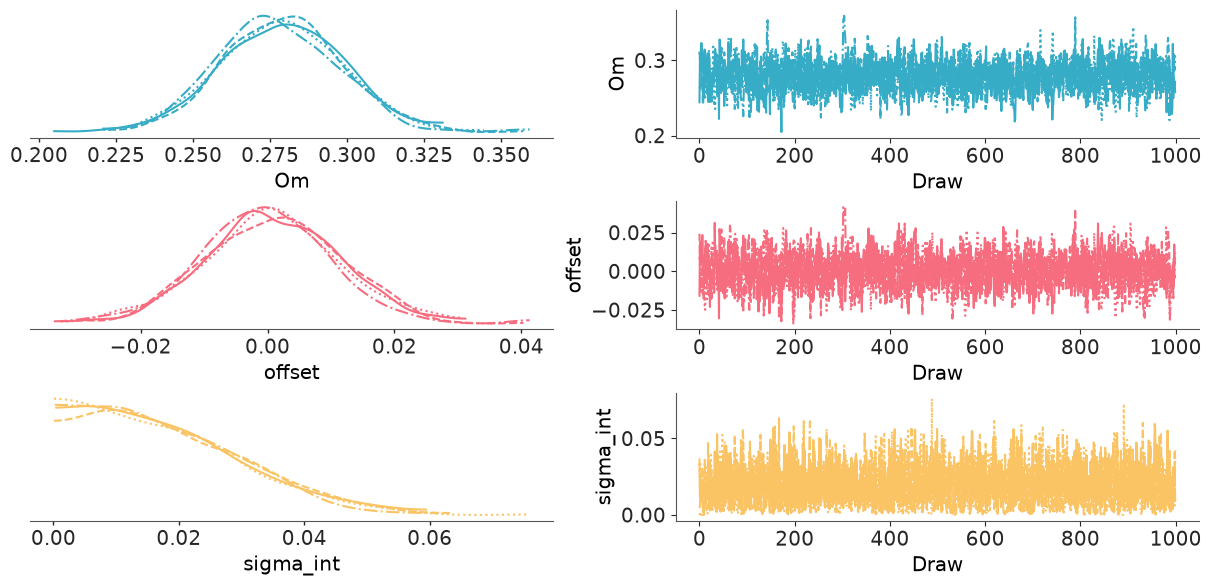

In [16]:
az.plot_trace_dist(flat_idata, var_names=["Om", "offset", "sigma_int"]);

No divergences, `r_hat` at 1.00, four chains on top of each other, and the offset is now
pinned to about $\pm 0.01$ mag. The effective sample size is "only" a third of the draws
because $\Omega_m$ and the offset are correlated at about 0.7 (a lower $\Omega_m$ makes
distant supernovae fainter; so does a higher offset) - plenty for our purposes. One
consequence worth knowing: `az.plot_rank`, which E01 recommended, draws its envelope for
*independent* draws, so with this much autocorrelation it tends to flag perfectly healthy
chains. Thin the draws before using it, or rely on `r_hat` and ESS, which account for
autocorrelation.

The physics:

- $\Omega_m \approx 0.28$: matter is only about 28% of the critical density, and if the
  universe is flat the other 72% is something that behaves like a cosmological constant.
- The offset is consistent with zero: the published $\mu$ indeed correspond to $h = 0.7$.
- $\sigma_\text{int}$ is **consistent with zero**, while Einstein-de Sitter needed 0.17 mag.
  Two lessons in one. First, the published errors evidently already contain an
  intrinsic-dispersion term (compilations like this one tune it so that the best fit has
  $\chi^2$ per degree of freedom near one - computed below), leaving nothing for ours to
  do. Second, a free scatter term is a **misfit sponge**: in model (a) it quietly soaked
  up the failure of the physics. A large "noise" estimate is a symptom worth chasing.

In [17]:
flat_post = az.extract(flat_idata)
mu_hat = mu_shape(z_obs, float(flat_post["Om"].mean()), 1 - float(flat_post["Om"].mean())) + MU0_FID
mu_hat = mu_hat + float(flat_post["offset"].mean())
print(f"chi^2 at the posterior mean, published errors only: {(((mu_obs - mu_hat) / mu_err) ** 2).sum():.1f} for {len(sn)} supernovae")
print(f"posterior correlation of Om and offset: {np.corrcoef(flat_post['Om'], flat_post['offset'])[0, 1]:.2f}")

chi^2 at the posterior mean, published errors only: 562.2 for 580 supernovae
posterior correlation of Om and offset: 0.73


### Posterior predictive checks: residuals against redshift

A histogram-style PPC is useless here (both models reproduce "a pile of numbers between 34
and 45"). The informative check is **structure in the residuals along $z$**. First the raw
version: standardised residuals with a running mean.

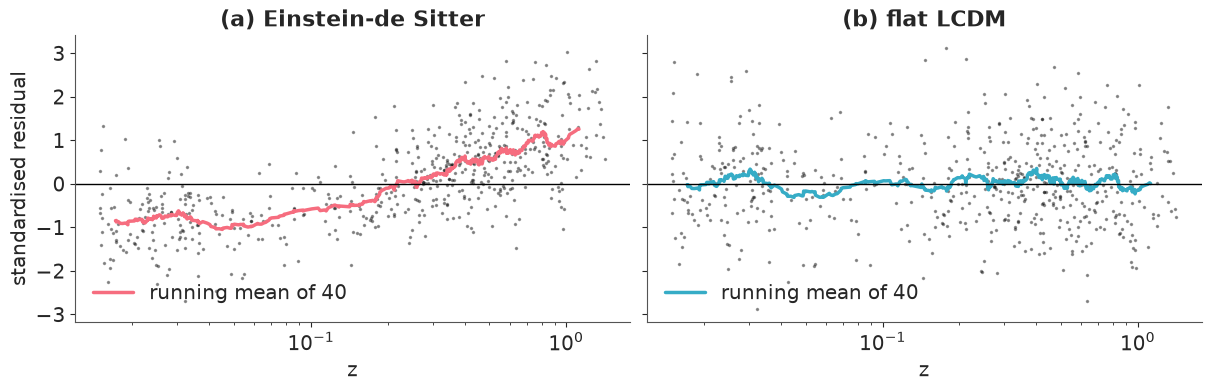

In [18]:
def standardised_residuals(idata):
    post = idata.posterior
    mu_mean = post["mu"].mean(("chain", "draw")).values
    sigma = np.sqrt(mu_err**2 + float(post["sigma_int"].mean()) ** 2)
    return (mu_obs - mu_mean) / sigma


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (label, idata, color) in zip(axes, [("(a) Einstein-de Sitter", eds_idata, "C1"),
                                            ("(b) flat LCDM", flat_idata, "C0")]):
    resid = standardised_residuals(idata)
    running = pd.Series(resid).rolling(40, center=True).mean()  # sn is sorted by z
    ax.plot(z_obs, resid, ".", ms=3, color="k", alpha=0.35)
    ax.plot(z_obs, running, color=color, lw=2.5, label="running mean of 40")
    ax.axhline(0, color="k", lw=1)
    ax.set(xscale="log", xlabel="z", title=label)
    ax.legend(loc="lower left")
axes[0].set(ylabel="standardised residual");

Einstein-de Sitter has a trend the offset cannot hide: nearby supernovae are brighter than
predicted, distant ones fainter, because the offset can only shift the curve up and down
to split the difference. Flat $\Lambda$CDM's running mean wobbles around zero with no trend
(its excursions are what a mean of 40 unit-variance numbers does: $\pm 0.16$).

Now the proper posterior predictive version. For each model, simulate replicated datasets,
reduce each to the 11 binned Hubble residuals relative to the empty universe, and ask
whether the observed binned residuals look like a draw from that distribution.

Sampling: [mu_obs]


Sampling: [mu_obs]


(a) Einstein-de Sitter: 9 of 11 observed bins outside the 94% band
(b) flat LCDM: 0 of 11 observed bins outside the 94% band


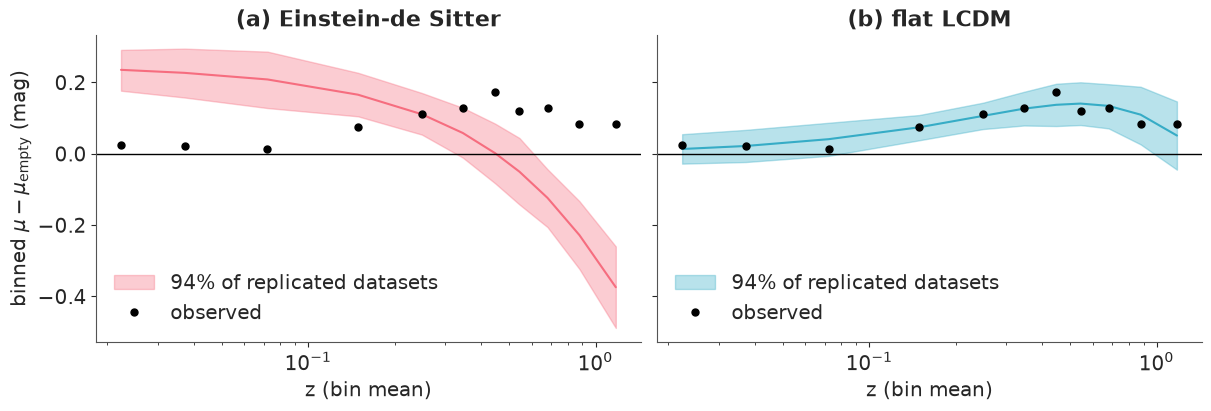

In [19]:
with eds_model:
    pm.sample_posterior_predictive(eds_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)
with flat_model:
    pm.sample_posterior_predictive(flat_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, idata, color) in zip(axes, [("(a) Einstein-de Sitter", eds_idata, "C1"),
                                            ("(b) flat LCDM", flat_idata, "C0")]):
    rep = az.extract(idata, group="posterior_predictive", var_names="mu_obs").transpose("sample", "sn").values
    rep_bin = binned_mean(rep - milne(z_obs))
    lo, hi = np.quantile(rep_bin, [0.03, 0.97], axis=0)
    ax.fill_between(z_bin, lo, hi, color=color, alpha=0.35, label="94% of replicated datasets")
    ax.plot(z_bin, rep_bin.mean(0), color=color)
    ax.plot(z_bin, resid_bin, "ko", ms=5, label="observed")
    ax.axhline(0, color="k", lw=1)
    ax.set(xscale="log", xlabel="z (bin mean)", title=label)
    ax.legend(loc="lower left")
    print(f"{label}: {int(((resid_bin < lo) | (resid_bin > hi)).sum())} of {n_bins} observed bins outside the 94% band")
axes[0].set(ylabel=r"binned $\mu - \mu_\mathrm{empty}$ (mag)");

This is the 1998 discovery in one figure. The observed points rise **above** the empty
universe out to $z \approx 0.5$ - supernovae are fainter than even a coasting universe
allows - and then turn over. A matter-only universe can only ever go down; even with its
inflated scatter and its 0.25 mag offset, most observed bins fall outside its predictive
band, in a systematic pattern (the model sits above the data at low $z$ and far below at
high $z$). Flat
$\Lambda$CDM tracks the rise and the turn-over.

### Heavy tails?

Supernova samples contain the odd misclassified or dust-reddened object, and a Gaussian
likelihood lets one bad point drag the fit. The standard robustness check is a Student-t
likelihood with the degrees of freedom $\nu$ free.

In [20]:
with pm.Model(coords=coords) as flat_t_model:
    Om = pm.Uniform("Om", 0.0, 1.0)
    hubble_likelihood(mu_shape(z_obs, Om, 1 - Om, xp=pt), student_t=True)
    flat_t_idata = pm.sample(**SAMPLE_KWARGS)

print("divergences:", int(flat_t_idata.sample_stats["diverging"].sum()))
az.summary(flat_t_idata, var_names=["Om", "offset", "sigma_int", "nu"], round_to=3)

NUTS[nutpie]: [Om, offset, sigma_int, nu]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Om,0.280,0.020,0.248,0.312,1568.121,1963.068,1.000,0.001,0.000
offset,-0.000,0.011,-0.018,0.017,1583.760,1746.168,1.000,0.000,0.000
sigma_int,0.015,0.011,0.001,0.036,1399.791,1073.486,1.002,0.000,0.000
nu,36.790,14.735,18.621,62.861,2671.932,2551.646,1.001,0.293,0.364


$\nu$ lands in the tens - essentially Gaussian - and $\Omega_m$ does not move. The heavy
tails are not needed; the compilation has evidently already been through outlier
rejection. We carry the Student-t model into the LOO table as a check and otherwise keep
the Normal likelihood.

### (c) Curved $\Lambda\text{CDM}$: the banana

Drop the flatness assumption and let $\Omega_m$ and $\Omega_\Lambda$ vary independently.
Physics gives $\Omega_m \ge 0$ but does not bound $\Omega_\Lambda$ (a negative cosmological
constant is perfectly legal), so we use a generous box.

One corner of that box is unphysical in an interesting way: for large $\Omega_\Lambda$ and
small $\Omega_m$, $E(z)^2$ goes negative at some redshift - a universe that bounced and
never had a Big Bang. `comoving_distance` clips $E^2$ at a tiny positive number there, which
makes the predicted distances absurdly large and the likelihood correspondingly terrible,
so the sampler stays away. We check afterwards that it did.

We take 2000 draws per chain here and in (d): two-dimensional contours of a curved
posterior need more draws than a marginal mean does.

In [21]:
with pm.Model(coords=coords) as curved_model:
    Om = pm.Uniform("Om", 0.0, 1.5)
    OL = pm.Uniform("OL", -1.0, 2.0)
    pm.Deterministic("Ok", 1 - Om - OL)
    pm.Deterministic("q0", Om / 2 - OL)
    hubble_likelihood(mu_shape(z_obs, Om, OL, xp=pt))
    curved_idata = pm.sample(draws=2000, **SAMPLE_KWARGS)

print("divergences:", int(curved_idata.sample_stats["diverging"].sum()))
az.summary(curved_idata, var_names=["Om", "OL", "Ok", "q0", "offset", "sigma_int"], round_to=3)

NUTS[nutpie]: [Om, OL, offset, sigma_int]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Om,0.277,0.070,0.161,0.384,1767.439,2034.933,1.002,0.002,0.001
OL,0.718,0.118,0.522,0.901,1544.954,2080.537,1.002,0.003,0.002
Ok,0.005,0.184,-0.277,0.311,1567.629,1912.003,1.001,0.005,0.003
q0,-0.579,0.088,-0.717,-0.434,1593.507,2322.729,1.001,0.002,0.001
offset,0.001,0.014,-0.021,0.022,2217.560,3039.687,1.001,0.000,0.000
sigma_int,0.018,0.013,0.002,0.041,2500.197,1801.674,1.004,0.000,0.000


In [22]:
curved_post = az.extract(curved_idata)
z_fine = np.linspace(0, z_obs.max(), 200)

box = rng.uniform([0.0, -1.0], [1.5, 2.0], size=(20_000, 2))
no_big_bang_prior = (E2(z_fine, box[:, :1], box[:, 1:]) <= 0).any(axis=1).mean()
E2_post = E2(z_fine, curved_post["Om"].values[:, None], curved_post["OL"].values[:, None])
print(f"share of the prior box with E^2 <= 0 inside the data range: {no_big_bang_prior:.1%}")
print(f"share of posterior draws with E^2 <= 0 anywhere           : {(E2_post <= 0).any(axis=1).mean():.1%}")
print(f"posterior correlation of Om and OL: {np.corrcoef(curved_post['Om'], curved_post['OL'])[0, 1]:.2f}")

share of the prior box with E^2 <= 0 inside the data range: 4.2%
share of posterior draws with E^2 <= 0 anywhere           : 0.0%
posterior correlation of Om and OL: 0.90


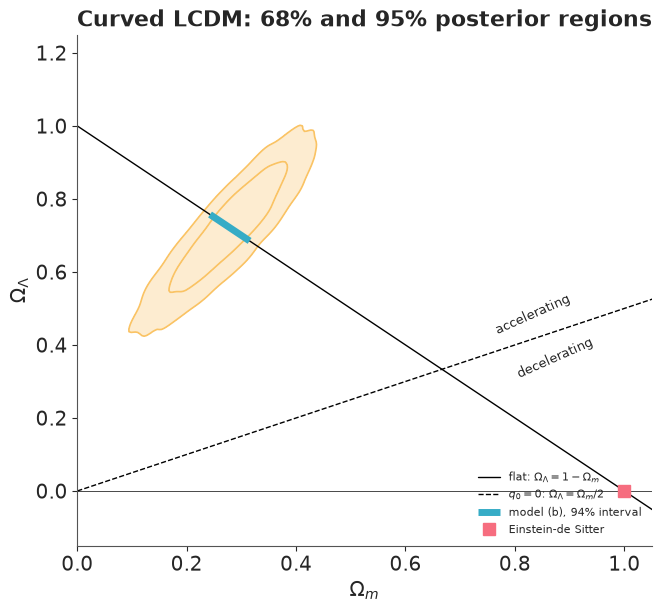

In [23]:
def hdr_contours(ax, x, y, color, levels=(0.95, 0.68), grid=120, **kwargs):
    """Highest-density-region contours enclosing the given posterior masses (Gaussian KDE)."""
    kde = stats.gaussian_kde(np.vstack([x, y]))
    xx, yy = np.meshgrid(np.linspace(x.min(), x.max(), grid), np.linspace(y.min(), y.max(), grid))
    dens = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    dens_at_draws = np.sort(kde(np.vstack([x[::4], y[::4]])))
    cuts = [dens_at_draws[int((1 - level) * len(dens_at_draws))] for level in levels]
    ax.contourf(xx, yy, dens, levels=[*cuts, np.inf], colors=[color], alpha=0.3, **kwargs)
    ax.contour(xx, yy, dens, levels=cuts, colors=[color], linewidths=1.2)


om_line = np.linspace(0, 1.5, 50)
flat_lo, flat_hi = np.quantile(flat_post["Om"].values, [0.03, 0.97])

fig, ax = plt.subplots(figsize=(6.5, 6))
hdr_contours(ax, curved_post["Om"].values, curved_post["OL"].values, "C2")
ax.plot(om_line, 1 - om_line, "k-", lw=1, label=r"flat: $\Omega_\Lambda = 1 - \Omega_m$")
ax.plot(om_line, om_line / 2, "k--", lw=1, label=r"$q_0 = 0$: $\Omega_\Lambda = \Omega_m/2$")
ax.plot([flat_lo, flat_hi], [1 - flat_lo, 1 - flat_hi], color="C0", lw=5, solid_capstyle="butt",
        label="model (b), 94% interval")
ax.axhline(0, color="k", lw=0.5)
ax.plot(1, 0, "s", color="C1", ms=8, label="Einstein-de Sitter")
ax.text(0.76, 0.43, "accelerating", rotation=24, fontsize=9)
ax.text(0.80, 0.31, "decelerating", rotation=24, fontsize=9)
ax.set(xlim=(0, 1.05), ylim=(-0.15, 1.25), xlabel=r"$\Omega_m$", ylabel=r"$\Omega_\Lambda$",
       title="Curved LCDM: 68% and 95% posterior regions")
ax.legend(loc="lower right", fontsize=8);

The famous picture. Supernovae do not measure $\Omega_m$ and $\Omega_\Lambda$ separately:
they measure, roughly, the *difference* between brake and accelerator, so the posterior is
a long diagonal ridge - the two are correlated at about 0.9 - and the marginal
uncertainties are 3.5 times ($\Omega_m$) and 6 times ($\Omega_\Lambda$) what they were in
the flat model. Unlike the $H_0$-$M$ ridge, this one is a **soft** degeneracy: it has finite
length because the redshift lever arm distinguishes the two terms a little, and NUTS
handles it without complaint.

What the banana does and does not say:

- It lies **entirely above** the dashed $q_0 = 0$ line and above $\Omega_\Lambda = 0$.
  Acceleration does not depend on assuming flatness.
- It is **consistent with flat**: the solid line runs through the middle, and
  $\Omega_k = 0$ is well inside its posterior. But supernovae alone constrain curvature
  poorly ($\pm 0.2$); it is the CMB that nails flatness, which is why combining probes whose
  degeneracy directions cross is so powerful.
- Einstein-de Sitter is nowhere near.

### (d) Flat $w\text{CDM}$: is dark energy a cosmological constant?

Keep flatness, free the equation of state. The prior $w \sim \text{Uniform}(-3, 0)$ is
deliberately agnostic: it includes "phantom" dark energy ($w < -1$) and components that
would not accelerate anything ($w > -1/3$).

In [24]:
with pm.Model(coords=coords) as wcdm_model:
    Om = pm.Uniform("Om", 0.0, 1.0)
    w = pm.Uniform("w", -3.0, 0.0)
    pm.Deterministic("q0", 0.5 + 1.5 * w * (1 - Om))
    hubble_likelihood(mu_shape(z_obs, Om, 1 - Om, w, xp=pt))
    wcdm_idata = pm.sample(draws=2000, **SAMPLE_KWARGS)

print("divergences:", int(wcdm_idata.sample_stats["diverging"].sum()))
az.summary(wcdm_idata, var_names=["Om", "w", "q0", "offset", "sigma_int"], round_to=3)

NUTS[nutpie]: [Om, w, offset, sigma_int]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Om,0.275,0.076,0.135,0.381,1301.812,1216.097,1.004,0.002,0.002
w,-1.030,0.203,-1.362,-0.720,1238.854,1231.144,1.005,0.006,0.004
q0,-0.598,0.114,-0.787,-0.426,1330.264,1639.679,1.004,0.003,0.002
offset,-0.001,0.015,-0.025,0.023,1954.683,2768.183,1.002,0.000,0.000
sigma_int,0.018,0.013,0.002,0.041,2469.331,2123.504,1.002,0.000,0.000


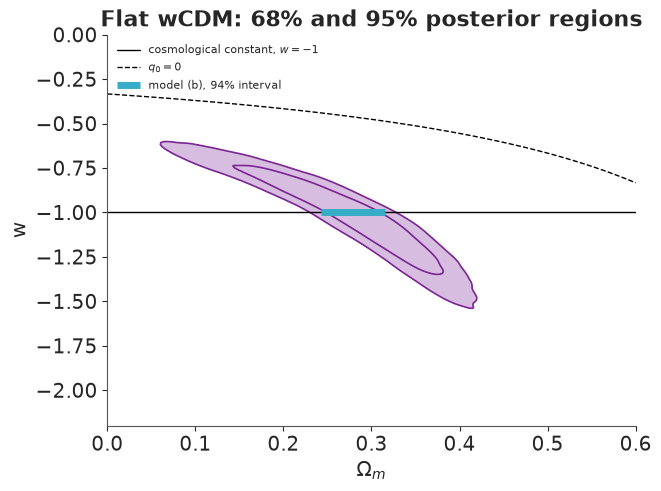

In [25]:
wcdm_post = az.extract(wcdm_idata)
om_line = np.linspace(0, 0.6, 100)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
hdr_contours(ax, wcdm_post["Om"].values, wcdm_post["w"].values, "C3")
ax.axhline(-1, color="k", lw=1, label=r"cosmological constant, $w=-1$")
ax.plot(om_line, -1 / (3 * (1 - om_line)), "k--", lw=1, label=r"$q_0 = 0$")
ax.plot([flat_lo, flat_hi], [-1, -1], color="C0", lw=5, solid_capstyle="butt", label="model (b), 94% interval")
ax.set(xlim=(0, 0.6), ylim=(-2.2, 0), xlabel=r"$\Omega_m$", ylabel="w",
       title="Flat wCDM: 68% and 95% posterior regions")
ax.legend(loc="upper left", fontsize=8);

Another banana, this time genuinely bent: more matter can be compensated by more negative
pressure. $w = -1$ passes straight through the middle, so the data are perfectly happy
with a cosmological constant - but on their own they allow anything from about $-1.4$ to
$-0.7$, and the 95% region stretches from $\Omega_m < 0.1$ to above 0.4. The whole
posterior stays below the $q_0 = 0$ curve. An external constraint on $\Omega_m$ (BAO, CMB) would slice the
banana vertically and tighten $w$ dramatically - see *Try it yourself*.

### LOO: which universe predicts held-out supernovae best?

In [26]:
idatas = {"(a) Einstein-de Sitter": (eds_model, eds_idata), "(b) flat LCDM": (flat_model, flat_idata),
          "(b') flat LCDM, Student-t": (flat_t_model, flat_t_idata),
          "(c) curved LCDM": (curved_model, curved_idata), "(d) flat wCDM": (wcdm_model, wcdm_idata)}
for model, idata in idatas.values():
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)

comparison = az.compare({name: idata for name, (_, idata) in idatas.items()}, round_to=1)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
(b) flat LCDM,0,0.0,0.0,NaN,,,1.9,116.3,20.3,1.0
"(b') flat LCDM, Student-t",1,-0.8,1.0,0.8,|elpd_diff| < 4,,1.9,115.5,19.7,0.0
(d) flat wCDM,2,-0.9,0.1,1.0,|elpd_diff| < 4,,2.8,115.4,20.3,0.0
(c) curved LCDM,3,-1.0,0.1,1.0,|elpd_diff| < 4,,2.8,115.4,20.3,0.0
(a) Einstein-de Sitter,4,-219.6,16.9,1.0,,,2.0,-103.3,19.7,0.0


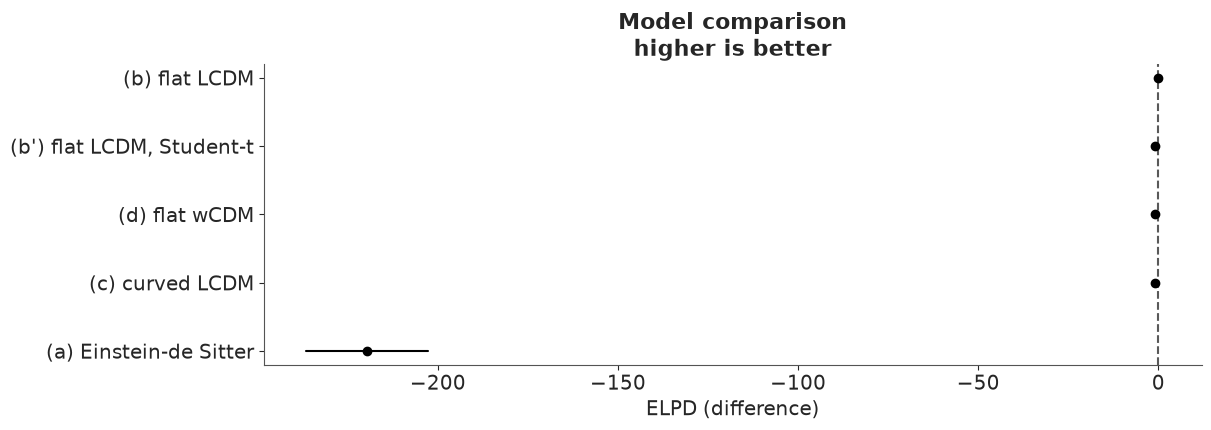

In [27]:
az.plot_compare(comparison);

Two very different verdicts, and both matter:

- **Einstein-de Sitter is out**, by more than 200 units of elpd - over ten standard errors
  of the difference. Note this is *after* it was allowed to inflate $\sigma_\text{int}$ to
  protect itself; without that freedom it would look far worse. Here LOO is answering a
  physics question: a universe with only matter in it does not predict supernova
  brightnesses, and one with a cosmological constant does.
- **Among the dark-energy models LOO cannot choose**, and says so: the differences are
  below one unit, far inside the $|\text{elpd\_diff}| < 4$ zone where ArviZ itself warns
  against reading anything into the ranking. Curvature and $w$ each cost about one
  effective parameter (`p`) and buy no predictive accuracy. That is not evidence that the
  universe is flat or that $w=-1$; it says these data cannot tell, which is exactly what
  the two bananas showed. The simplest adequate model is (b).

## 7 · From posterior to scientific answers

Parameters with physical meaning can be pushed through *more physics*, draw by draw.

**Is the expansion accelerating?** $P(q_0 < 0)$ under each dark-energy model:

In [28]:
q0_draws = {
    "(b) flat LCDM": 1.5 * flat_post["Om"].values - 1,
    "(c) curved LCDM": curved_post["q0"].values,
    "(d) flat wCDM": wcdm_post["q0"].values,
}
answers = pd.DataFrame({
    name: {"q0 mean": q.mean(), "q0 3%": np.quantile(q, 0.03), "q0 97%": np.quantile(q, 0.97),
           "largest q0 drawn": q.max(), "draws": len(q), "P(q0 < 0)": (q < 0).mean()}
    for name, q in q0_draws.items()
}).T
answers.round(3)

,q0 mean,q0 3%,q0 97%,largest q0 drawn,draws,P(q0 < 0)
(b) flat LCDM,-0.582,-0.636,-0.527,-0.461,4000.0,1.0
(c) curved LCDM,-0.579,-0.740,-0.408,-0.207,8000.0,1.0
(d) flat wCDM,-0.598,-0.823,-0.404,-0.286,8000.0,1.0


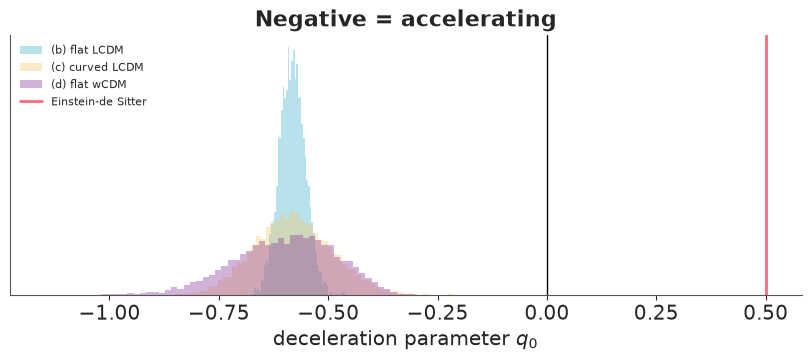

In [29]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for (name, q), color in zip(q0_draws.items(), ["C0", "C2", "C3"]):
    ax.hist(q, bins=60, density=True, histtype="stepfilled", alpha=0.35, color=color, label=name)
ax.axvline(0, color="k", lw=1)
ax.axvline(0.5, color="C1", lw=2, label="Einstein-de Sitter")
ax.set(xlabel=r"deceleration parameter $q_0$", yticks=[], title="Negative = accelerating")
ax.legend(fontsize=8);

Not a single posterior draw in any of the three models decelerates, so all a Monte Carlo
estimate can honestly say is that $P(\text{accelerating})$ exceeds $1 - 1/\text{draws}$.
Relaxing flatness or $w = -1$ widens $q_0$ by a factor of three to four but leaves it
centred near $-0.6$, many standard deviations from zero.

That probability is conditional on everything we assumed: a homogeneous universe obeying
general relativity, supernovae that are the same kind of candle at $z = 1$ as nearby, and
- importantly - the error model discussed in section 8.

**How much dark energy, when did acceleration begin, and how old is the universe?** For
$w = -1$, $\ddot a = 0$ when $\Omega_m (1+z)^3 = 2\,\Omega_\Lambda$, so the transition
redshift is $z_t = (2\Omega_\Lambda/\Omega_m)^{1/3} - 1$. The age is one more integral,

$$t_0 = \frac{1}{H_0}\int_0^1 \frac{da}{a\,E(a)}
= \frac{1}{H_0}\int_0^1 \frac{2u^2\,du}{\sqrt{\Omega_m + \Omega_k u^2 + \Omega_\Lambda u^6}}
\qquad (a = \tfrac{1}{1+z} = u^2),$$

where the substitution removes the square-root singularity at the Big Bang so that
Gauss-Legendre converges fast. No gradients are needed now, so this is plain NumPy on the
posterior draws. It needs an $H_0$, which - section 4 - supernovae cannot supply: we
**condition on** $h = 0.7$, and $t_0$ scales as $1/h$.

In [30]:
KM_PER_MPC, SEC_PER_GYR = 3.0856775814913673e19, 3.15576e16
HUBBLE_TIME_GYR = KM_PER_MPC / H0_FID / SEC_PER_GYR  # 1/H0 for h = 0.7


def age_gyr(Om, OL, n_nodes=32):
    """Age of a w = -1 universe in Gyr for h = 0.7; Om, OL are arrays of posterior draws."""
    x_k, w_k = np.polynomial.legendre.leggauss(n_nodes)
    u = 0.5 * (x_k + 1)
    Om, OL = Om[..., None], OL[..., None]
    integrand = 2 * u**2 / np.sqrt(Om + (1 - Om - OL) * u**2 + OL * u**6)
    return HUBBLE_TIME_GYR * 0.5 * (w_k * integrand).sum(-1)


# check: quad on the un-substituted integral, and the closed form for a flat universe
quad_age = HUBBLE_TIME_GYR * integrate.quad(lambda a: 1 / np.sqrt(0.3 / a + 0.7 * a**2), 0, 1)[0]
closed_form = HUBBLE_TIME_GYR * 2 / (3 * np.sqrt(0.7)) * np.arcsinh(np.sqrt(0.7 / 0.3))
print(f"1/H0 = {HUBBLE_TIME_GYR:.2f} Gyr;  age(Om=0.3, flat): quadrature {age_gyr(np.array(0.3), np.array(0.7)):.4f}, "
      f"quad {quad_age:.4f}, closed form {closed_form:.4f} Gyr")

Om_flat = flat_post["Om"].values
derived = {
    r"Omega_Lambda": 1 - Om_flat,
    r"q0": 1.5 * Om_flat - 1,
    r"transition redshift z_t": (2 * (1 - Om_flat) / Om_flat) ** (1 / 3) - 1,
    r"age (Gyr), given h = 0.7": age_gyr(Om_flat, 1 - Om_flat),
    r"age in units of 1/H0": age_gyr(Om_flat, 1 - Om_flat) / HUBBLE_TIME_GYR,
}
pd.DataFrame({k: {"mean": v.mean(), "sd": v.std(), "3%": np.quantile(v, 0.03), "97%": np.quantile(v, 0.97)}
              for k, v in derived.items()}).T.round(3)

1/H0 = 13.97 Gyr;  age(Om=0.3, flat): quadrature 13.4670, quad 13.4670, closed form 13.4670 Gyr


,mean,sd,3%,97%
Omega_Lambda,0.721,0.020,0.685,0.757
q0,-0.582,0.029,-0.636,-0.527
transition redshift z_t,0.732,0.056,0.632,0.841
"age (Gyr), given h = 0.7",13.758,0.268,13.284,14.276
age in units of 1/H0,0.985,0.019,0.951,1.022


Under flat $\Lambda\text{CDM}$: dark energy is about 72% of the universe; the expansion switched
from slowing down to speeding up at $z_t \approx 0.73$ - *inside* the redshift range of the
data, which is why the turn-over in the residual plot is visible at all - and the universe
is about 13.8 billion years old **if** $h = 0.7$. The last row is the assumption-free
version of that statement: the age is $0.985 \pm 0.02$ Hubble times. (For Einstein-de
Sitter it would be exactly $2/3$ of a Hubble time, 9.3 Gyr for $h = 0.7$ - younger than the
oldest stars, one of the pre-1998 hints that something was missing.)

### The four universes, and the extrapolation

Posterior mean and 94% band of each model's curve (with its own offset) against the binned
data, continued beyond the last supernova.

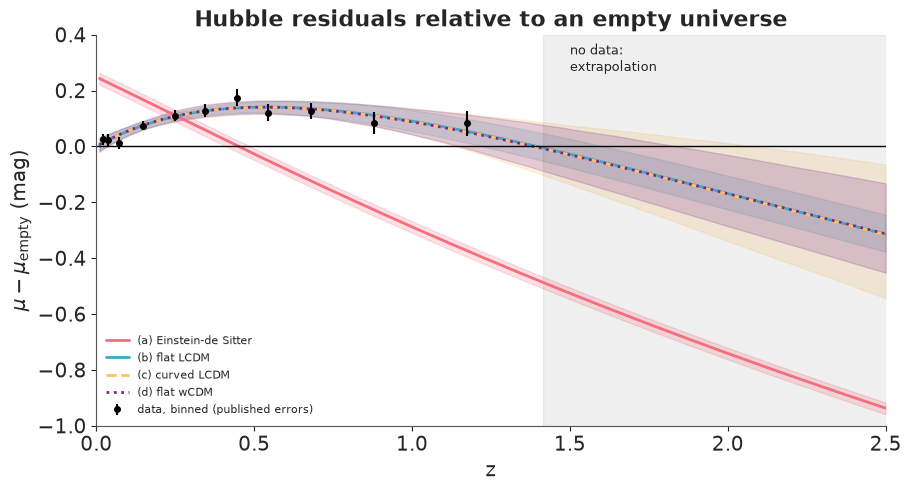

In [31]:
def residual_curves(post, Om, OL, w=-1.0, n=1000):
    """Posterior draws of mu(z_grid) - mu_empty(z_grid), including each draw's offset."""
    idx = rng.choice(post.sizes["sample"], size=n, replace=False)
    pick = lambda p: p[idx, None] if np.ndim(p) else p
    return mu_shape(z_grid, pick(Om), pick(OL), pick(w)) + MU0_FID + post["offset"].values[idx, None] - milne(z_grid)


eds_post = az.extract(eds_idata)
curves = {
    "(a) Einstein-de Sitter": (residual_curves(eds_post, 1.0, 0.0), "C1"),
    "(b) flat LCDM": (residual_curves(flat_post, Om_flat, 1 - Om_flat), "C0"),
    "(c) curved LCDM": (residual_curves(curved_post, curved_post["Om"].values, curved_post["OL"].values), "C2"),
    "(d) flat wCDM": (residual_curves(wcdm_post, wcdm_post["Om"].values, 1 - wcdm_post["Om"].values,
                                      wcdm_post["w"].values), "C3"),
}

fig, ax = plt.subplots(figsize=(9, 4.8))
for (name, (curve, color)), ls in zip(curves.items(), ["-", "-", "--", ":"]):
    lo, hi = np.quantile(curve, [0.03, 0.97], axis=0)
    ax.fill_between(z_grid, lo, hi, color=color, alpha=0.2)
    ax.plot(z_grid, curve.mean(0), color=color, ls=ls, lw=2, label=name)
ax.errorbar(z_bin, resid_bin, yerr=resid_bin_se, fmt="ko", ms=4, label="data, binned (published errors)")
ax.axhline(0, color="k", lw=1)
ax.axvspan(z_obs.max(), z_grid.max(), color="k", alpha=0.06)
ax.text(1.5, 0.27, "no data:\nextrapolation", fontsize=9)
ax.set(xlim=(0, 2.5), ylim=(-1.0, 0.4), xlabel="z", ylabel=r"$\mu - \mu_\mathrm{empty}$ (mag)",
       title="Hubble residuals relative to an empty universe")
ax.legend(loc="lower left", fontsize=8);

Inside the data the three dark-energy models are indistinguishable - as LOO said. Beyond
$z = 1.4$ they are still all **physically sensible** curves: each bends back down, because
in any of these universes matter dominated early on and the expansion was decelerating.
The bands widen in the grey region, the more flexible models more so, and that widening
is itself informative: it says precisely which future observations ($z > 1.5$
supernovae) would discriminate between them. A spline or polynomial fitted to the same
points has no such anchor: nothing in it knows that matter must win at early times.

## 8 · What we did not model

- **Systematics.** We used only the diagonal `mu_err`. The real analysis has a full
  $580 \times 580$ covariance matrix: calibration, dust and light-curve-model
  uncertainties shift *groups* of supernovae together, which is far more damaging to a
  measurement of shape than independent noise. In the Union2.1 paper, including it
  roughly doubles the uncertainty on $\Omega_m$. Our intervals are **too narrow**, and
  statements like "many standard deviations from zero" should be read with that in
  mind (the qualitative conclusions survive). With the matrix in hand the change to the
  model is small: `pm.MvNormal` with the full covariance in place of `pm.Normal`.
- **The standardisation itself.** The published $\mu$ are the output of a light-curve fit
  (stretch and colour corrections) whose coefficients were estimated together with a
  cosmology. A fully Bayesian treatment models light-curve parameters and cosmology
  jointly, hierarchically.
- **Astrophysics.** Supernovae in low-mass host galaxies are slightly fainter after
  standardisation; the column `p_low_mass_host` is there to model it (below).

## Recap

| | |
|---|---|
| Theory as regression function | one function `mu_shape`, four models as constraints on it; parameters you can look up in a textbook |
| Integral inside the model | fixed-order Gauss-Legendre in plain PyTensor arithmetic; verified against `quad` to $10^{-14}$ mag; a power series instead of branching for $\text{sinn}$ |
| What went wrong | $H_0$ and $M$ are exactly degenerate: bad `r_hat`, posterior = prior along a ridge. Fix the *model* (sample the identified combination), not the sampler |
| Misfit sponge | Einstein-de Sitter sampled perfectly and hid its failure in $\sigma_\text{int}$; residuals against $z$ exposed it |
| Soft degeneracies | the $(\Omega_m,\Omega_\Lambda)$ and $(\Omega_m, w)$ bananas are real features of what the data can say - report them, do not fight them |
| LOO | decisive where the physics differs (matter-only vs dark energy), honest where the data cannot tell (curvature, $w$) |

### Try it yourself

1. **Host-mass step.** Add a term $\Delta_\text{host}\cdot$`p_low_mass_host` to `mu` in
   `hubble_likelihood` (the column is the probability that the host galaxy has low stellar
   mass). Is $\Delta_\text{host}$ distinguishable from zero, which sign does it have, and
   does $\Omega_m$ move? Think about why a population drift with redshift would matter.
2. **Break the $w$ degeneracy with an external probe.** Replace the uniform prior on
   $\Omega_m$ in model (d) by an informative Gaussian standing in for BAO + CMB, say
   `pm.Normal("Om", 0.30, 0.02)` truncated to $(0, 1)$. How much does the interval on $w$
   shrink? Redraw the banana with the old one behind it.
3. **Time-varying dark energy.** Implement the CPL parametrisation
   $w(a) = w_0 + w_a(1-a)$, for which the dark-energy term in $E(z)^2$ becomes
   $\Omega_\Lambda (1+z)^{3(1+w_0+w_a)}\exp\!\big(-3 w_a z/(1+z)\big)$. Only `E2` needs to
   change. Expect the sampler to work hard: look at the $(w_0, w_a)$ pair plot, check
   `r_hat`, and decide what prior information on $w_a$ you can defend.

Next: **E09**, where the numerics are too involved for plain PyTensor and come in through
`pytensor.wrap_jax` instead.